# Installing extra library

In [4]:
!python -m pip install --upgrade pip

In [8]:
!pip install -r requirements.txt

  Using cached scikit_learn_intelex-2025.11.0-py312-none-win_amd64.whl.metadata (10 kB)
Using cached scikit_learn_intelex-2025.11.0-py312-none-win_amd64.whl (3.2 MB)


In [10]:
from sklearnex import patch_sklearn
patch_sklearn()

Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


# Data Fetch and Load


In [11]:
root = "philmorekoung11/luxury-watch-listings"
path = "Watches.csv"

In [12]:
import os
import kagglehub
def fetch():
    print ('I am fetching, hihi...')
    try:
        dataset_path = kagglehub.dataset_download(root)
        print ("Fetch successfully")
        print (f"Dataset is saved at {dataset_path}")
        return dataset_path
    except Exception as e:
        print (f"Fetch fail!, Error: {e}")
        return None
data_path = fetch()

I am fetching, hihi...
Fetch successfully
Dataset is saved at C:\Users\alexh\.cache\kagglehub\datasets\philmorekoung11\luxury-watch-listings\versions\1


In [13]:
import pandas as pd
def load():
    csv_path = os.path.join (data_path, path)
    return pd.read_csv(csv_path, low_memory=False)
watches_original = load()

# Data Overview


In [14]:
watches = watches_original.copy()
watches.info()

<class 'pandas.DataFrame'>
RangeIndex: 284491 entries, 0 to 284490
Data columns (total 14 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   Unnamed: 0  284491 non-null  int64
 1   name        211906 non-null  str  
 2   price       284085 non-null  str  
 3   brand       284360 non-null  str  
 4   model       254025 non-null  str  
 5   ref         241339 non-null  str  
 6   mvmt        87806 non-null   str  
 7   casem       120220 non-null  str  
 8   bracem      109595 non-null  str  
 9   yop         284357 non-null  str  
 10  cond        208504 non-null  str  
 11  sex         188686 non-null  str  
 12  size        260894 non-null  str  
 13  condition   71569 non-null   str  
dtypes: int64(1), str(13)
memory usage: 30.4 MB


In [15]:
watches.describe() 

,Unnamed: 0
count,284491.000000
mean,16027.513369
std,17410.945197
min,0.000000
25%,4199.000000
50%,9211.000000
75%,20556.000000
max,72584.000000


# Support preprocessing function


In [16]:
def nan_statistics(df: pd.DataFrame, features: list):
    if isinstance(features, str):
        features = [features]
    total = len (df)
    for feature in features:
        series = df[feature]
        name = series.name if series.name is not None else "Unnamed feature"
        nan_count = df[feature].isna().sum()
        not_nan_count = total - nan_count
        print (f"\n-------NaN statistics of '{name}' feature-------")
        print ("Not nan values count:", not_nan_count, )
        print ("Nan values count:", nan_count)
        print (f"Nan values account for {nan_count/total*100: .2f}%")

In [17]:
def nan_features(df: pd.DataFrame):
    return df.columns[df.isna().any()].tolist()

In [18]:
def price_comparor (df: pd.DataFrame, features: list):
    if isinstance(features, str):
        features = [features]
    for feature in features:
        series = df[feature]
        name = series.name if series.name is not None else "Unnamed Feature"
        print (f"\n-------Price '{name}' feature-------")
        missing_value = df[feature].isna()
        price_check = df.groupby(missing_value)['price'].agg (['median', 'mean', 'count'])
        print (price_check)

# 'price' preprocess


In [19]:
watches['price'].describe()

count               284085
unique               36830
top       Price on request
freq                 14259
Name: price, dtype: object

In [20]:
def count_price_request (watches): 
    price_df = watches['price']
    count = len (price_df[price_df == "Price on request"])
    print (f"Request count: {count}")
    print (f"This accounts for: {count / len (price_df): .2f}% of price features")

In [21]:
import numpy as np
price_request_index = watches[watches['price'] == "Price on request"].index
watches.loc[price_request_index, 'price'] = watches.dropna(subset=['ref']).groupby('ref')['price'].transform (
    lambda row: row.mode()[0] if not (row.mode().empty or row.mode()[0] == np.nan) else np.nan
)

count_price_request(watches)

Request count: 8838
This accounts for:  0.03% of price features


In [22]:
price_request_index = watches[watches['price'] == "Price on request"].index
watches.loc[price_request_index, 'price'] = watches.dropna(subset = ['brand', 'model']).groupby(['brand', 'model']).transform (
    lambda row: row.mode()[0] if not (row.mode().empty or row.mode()[0] == np.nan) else np.nan
)

count_price_request(watches)

Request count: 7977
This accounts for:  0.03% of price features


In [23]:
import numpy as np
import re
def price_convert_float(text: str):
    if not isinstance(text, str):
        return np.nan
    match = re.search(r"(\d+\,?\d*)", text)
    if match:
        value = match.group (1)
        value = value.replace (',', '')
        try:
            return float(value)
        except:
            return np.nan
        
    return np.nan
if watches['price'].dtype == "string" or watches['price'].dtype == "object":
    watches['price']=watches['price'].apply(price_convert_float)
nan_statistics(watches, 'price')


-------NaN statistics of 'price' feature-------
Not nan values count: 274268
Nan values count: 10223
Nan values account for  3.59%


In [24]:
watches = watches.dropna (subset = ['price'])

In [25]:
nan_features(watches)

['name',
 'model',
 'ref',
 'mvmt',
 'casem',
 'bracem',
 'cond',
 'sex',
 'size',
 'condition']

# 'ref' Preprocess


In [26]:
print (watches['ref'].head(), end = '\n' * 2)
nan_statistics(watches, 'ref')
price_comparor(watches, 'ref')

0    26237ST.OO.1000ST.01
1    15300ST.OO.1220ST.02
2                 26331ST
3    26715ST.OO.1356ST.01
4    26170ST.OO.1000ST.01
Name: ref, dtype: str


-------NaN statistics of 'ref' feature-------
Not nan values count: 233050
Nan values count: 41218
Nan values account for  15.03%

-------Price 'ref' feature-------
       median          mean   count
ref                                
False  7838.0  19342.249873  233050
True   2789.0   9514.449270   41218


In [27]:
def extract_ref_from_name(name: str):
    name = str(name)
    if name == "nan":
        return np.nan
    name_words = name.split()
    fallback = []

    for word in name_words:
        if not re.search (r"(\d+)", word):
            continue
        if re.search (r"([\/\.\,]+)", word):
            if not word.endswith('mm'):
                return word
        if len(word) > 2 and word.isalnum():
            if (
                len(word) > 4 or
                not word.startswith(('16', '17', '18', '19', '20'))
            ):
                fallback.append(word)
    if fallback:
        return fallback[0]
    return np.nan
missing_ref_values = watches[watches['ref'].isna()].index
watches.loc[missing_ref_values, 'ref'] = watches.loc[missing_ref_values, 'name'].apply (extract_ref_from_name)
nan_statistics(watches, 'ref')
price_comparor(watches, 'ref')


-------NaN statistics of 'ref' feature-------
Not nan values count: 257430
Nan values count: 16838
Nan values account for  6.14%

-------Price 'ref' feature-------
       median          mean   count
ref                                
False  7194.0  18382.282232  257430
True   3431.5   9961.217959   16838


In [28]:
watches['ref'] = watches['ref'].fillna(
    watches.dropna(subset=['brand', 'model', 'yop']).groupby(['brand', 'model', 'yop'])['ref'].transform (
        lambda row: row.mode()[0] if not (row.mode().empty or row.mode()[0] == np.nan) else np.nan
    )
)
nan_statistics (watches, 'ref')
price_comparor(watches, 'ref')


-------NaN statistics of 'ref' feature-------
Not nan values count: 265592
Nan values count: 8676
Nan values account for  3.16%

-------Price 'ref' feature-------
       median          mean   count
ref                                
False  7131.0  18215.048085  265592
True   2442.0   7158.466113    8676


In [29]:
watches = watches.dropna(subset=['ref'])

In [30]:
nan_features(watches)

['name',
 'model',
 'mvmt',
 'casem',
 'bracem',
 'cond',
 'sex',
 'size',
 'condition']

# 'cond' & 'condition' preprocess


In [31]:
watches[['cond', 'condition']].info()

<class 'pandas.DataFrame'>
Index: 265592 entries, 0 to 284490
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   cond       194481 non-null  str  
 1   condition  67636 non-null   str  
dtypes: str(2)
memory usage: 6.1 MB


In [32]:
watches['cond'] = watches['cond'].combine_first(watches['condition'])
nan_statistics(watches, 'cond')
price_comparor(watches, 'cond')


-------NaN statistics of 'cond' feature-------
Not nan values count: 262117
Nan values count: 3475
Nan values account for  1.31%

-------Price 'cond' feature-------
       median          mean   count
cond                               
False  7132.0  18184.953410  262117
True   6840.0  20485.069928    3475


In [33]:
watches = watches.dropna(subset = ['cond'])
if 'condition' in watches.columns:
    watches = watches.drop('condition', axis = 1)
print (watches['cond'].unique())

<StringArray>
['Unworn', 'Very good', 'New', 'Good', 'Fair', 'Poor', 'Incomplete']
Length: 7, dtype: str


In [34]:

condition_ranking = {
    'Incomplete': float(1),
    'Poor': float(2),
    'Fair': float(3),
    'Good': float(4),
    'Very good': float(5), 
    'Unworn': float(6),
    'New': float(7),
}

watches['cond'] = watches['cond'].map(condition_ranking)

In [35]:
watches = watches.dropna(subset = ['cond'])

In [36]:
nan_features(watches)

['name', 'model', 'mvmt', 'casem', 'bracem', 'sex', 'size']

# 'size' preprocess


In [37]:
print(watches['size'].unique(), end = '\n' * 2)
price_comparor(watches, 'size')
nan_statistics(watches, 'size')

<StringArray>
[           '42 mm',            '39 mm',            '41 mm',
            '38 mm',       '42 x 54 mm',            '44 mm',
            '37 mm',                nan,     '34 x 9.80 mm',
            '34 mm',
 ...
     '42 x 9.45 mm',       '31 x 46 mm',    '42 x 12.75 mm',
 '37.50 x 43.88 mm',     '48 x 15.8 mm',     '36.5 x 51 mm',
    '41 x 10.75 mm',    '40 x 10.75 mm',       '46 x 17 mm',
     '48 x 57.5 mm']
Length: 5980, dtype: str


-------Price 'size' feature-------
       median          mean   count
size                               
False  7327.0  18168.803738  241621
True   4775.0  18375.336895   20496

-------NaN statistics of 'size' feature-------
Not nan values count: 241621
Nan values count: 20496
Nan values account for  7.82%


In [38]:
if watches['size'].dtype == "string" or watches['size'].dtype == "object":
    watches['size'] = watches['size'].str.extract (r"(\d+\.?\d*)").astype(float)

In [39]:
def extract_size_from_name(name: str):
    name = str(name)
    if name == "nan":
        return np.nan
    match = re.search (r"(\d+\.?\d*)\s*mm", name)
    if match:
        value = match.group(1)
        return float (value)
    return np.nan

missing_size_index = watches[watches['size'].isna()].index
if watches['size'].dtype == 'string' or watches['size'].dtype == 'object':
    watches.loc[missing_size_index, 'size'] = watches.loc[missing_ref_values, 'name'].apply (extract_size_from_name)

In [40]:
missing_size_index = watches[watches['size'].isna()].index
watches.loc[missing_size_index, 'size'] = watches.dropna(subset = ['ref']).groupby('ref')['size'].transform ('first')
nan_statistics(watches, 'size')
price_comparor(watches, 'size')


-------NaN statistics of 'size' feature-------
Not nan values count: 257008
Nan values count: 5109
Nan values account for  1.95%

-------Price 'size' feature-------
       median          mean   count
size                               
False  7241.0  18186.997078  257008
True   2256.0  18082.146800    5109


In [41]:
missing_size_index = watches[watches['size'].isna()].index
watches.loc[missing_size_index, 'size'] = watches.dropna(subset = ['brand', 'model']).groupby(['brand', 'model'])['size'].transform (
    lambda row: row.fillna (np.ceil(row.median()))
)
nan_statistics(watches, 'size')
price_comparor(watches, 'size')


-------NaN statistics of 'size' feature-------
Not nan values count: 260987
Nan values count: 1130
Nan values account for  0.43%

-------Price 'size' feature-------
       median          mean   count
size                               
False  7161.0  18220.388644  260987
True   1388.0  10000.762832    1130


In [42]:
missing_size_index = watches[watches['size'].isna()].index
watches.loc[missing_size_index, 'size'] = watches.dropna (subset=['brand', 'sex', 'yop']).groupby (['brand', 'sex', 'yop'])['size'].transform (
    lambda row: row.fillna(np.ceil(row.median()))
)

nan_statistics(watches, 'size')
price_comparor(watches, 'size')


-------NaN statistics of 'size' feature-------
Not nan values count: 261708
Nan values count: 409
Nan values account for  0.16%

-------Price 'size' feature-------
       median          mean   count
size                               
False  7150.0  18206.599791  261708
True    521.0   4334.022005     409


In [43]:
missing_size_index = watches[watches['size'].isna()].index
watches.loc[missing_size_index, 'size'] = watches.dropna (subset=['brand', 'casem', 'bracem']).groupby (['brand', 'casem'])['size'].transform (
    lambda row: row.fillna(np.ceil(row.median()))
)

nan_statistics(watches, 'size')
price_comparor(watches, 'size')


-------NaN statistics of 'size' feature-------
Not nan values count: 261711
Nan values count: 406
Nan values account for  0.15%

-------Price 'size' feature-------
       median          mean   count
size                               
False  7150.0  18206.464222  261711
True    521.0   4318.903941     406


In [44]:
watches = watches.dropna(subset=['size'])

In [45]:
nan_features (watches)

['name', 'model', 'mvmt', 'casem', 'bracem', 'sex']

# 'year' preprocess


In [46]:
print (watches['yop'].unique(), end = '\n' * 2)
nan_statistics(watches, 'yop')
price_comparor (watches, 'yop')

<StringArray>
[                '2019',                 '2012',              'Unknown',
 '2022 (Approximation)', '2018 (Approximation)', '2016 (Approximation)',
                 '2015',                 '2016',                 '2022',
                 '2014',
 ...
                 '1887', '1871 (Approximation)',                 '1872',
                 '1880', '1650 (Approximation)', '1913 (Approximation)',
 '1918 (Approximation)', '1904 (Approximation)', '1914 (Approximation)',
 '1922 (Approximation)']
Length: 266, dtype: str


-------NaN statistics of 'yop' feature-------
Not nan values count: 261711
Nan values count: 0
Nan values account for  0.00%

-------Price 'yop' feature-------
       median          mean   count
yop                                
False  7150.0  18206.464222  261711


In [47]:
if watches['yop'].dtype == "string" or watches['yop'].dtype == object:
    watches['yop'] = watches['yop'].str.extract(r"(\d+)").astype(float)

price_comparor(watches, 'yop')
nan_statistics(watches, 'yop')


-------Price 'yop' feature-------
       median          mean   count
yop                                
False  8083.0  19816.955637  174310
True   5500.0  14994.547213   87401

-------NaN statistics of 'yop' feature-------
Not nan values count: 174310
Nan values count: 87401
Nan values account for  33.40%


In [48]:
def extract_year_from_name (name: str):
    name = str(name)
    if name == 'nan':
        return np.nan
    name_words = name.split()
    for word in name_words:
        if len(word) != 4 or not word.isdigit():
            continue
        word = float (word)
        if word >= 1500.0 and word <= 2026.0:
            return word
    return np.nan

watches['yop'] = watches['yop'].fillna(watches['name'].apply(extract_year_from_name))

price_comparor(watches, 'yop')
nan_statistics(watches, 'yop')


-------Price 'yop' feature-------
       median          mean   count
yop                                
False  8030.0  19636.630724  177255
True   5495.0  15204.851982   84456

-------NaN statistics of 'yop' feature-------
Not nan values count: 177255
Nan values count: 84456
Nan values account for  32.27%


In [49]:
watches['yop'] = watches['yop'].fillna(
    watches.dropna(subset=['brand', 'model']).groupby(['brand', 'model'])['yop'].transform (
        lambda row: np.ceil(row.median())
    )
)
nan_statistics(watches, 'yop')


-------NaN statistics of 'yop' feature-------
Not nan values count: 251656
Nan values count: 10055
Nan values account for  3.84%


In [50]:
watches['yop'] = watches['yop'].fillna(
    watches.dropna(subset = ['brand', 'size']).groupby(['brand', 'size'])['yop'].transform (
        lambda row: np.ceil(row.median())
    )
)
nan_statistics(watches, 'yop')


-------NaN statistics of 'yop' feature-------
Not nan values count: 261506
Nan values count: 205
Nan values account for  0.08%


In [51]:
watches = watches.dropna(subset = ['yop'])

In [52]:
nan_features (watches)

['name', 'model', 'mvmt', 'casem', 'bracem', 'sex']

# 'model' preprocess


In [53]:
print (watches['model'].unique(), end = '\n'* 2)
nan_statistics(watches, 'model')
price_comparor(watches, 'model')

<StringArray>
[           'Royal Oak Offshore Chronograph',
                     'Royal Oak Selfwinding',
                     'Royal Oak Chronograph',
                  'Royal Oak Offshore Diver',
      'Royal Oak Offshore Diver Chronograph',
                       'Royal Oak Dual Time',
 'Royal Oak Double Balance Wheel Openworked',
                      'Royal Oak Tourbillon',
                                 'Royal Oak',
                            'Royal Oak Lady',
 ...
                     'El Primero 36'000 VpH',
                                    'Sporto',
               'El Primero Big Date Special',
                                'Elite 6150',
                                 'Baby Star',
                          'New Vintage 1965',
                       'El Primero Synopsis',
                    'El Primero Lightweight',
              'El Primero Stratos Spindrift',
                     'Captain Power Reserve']
Length: 941, dtype: str


-------NaN statistics of 'model' fe

In [54]:
model_set = watches['model'].dropna().str.lower().unique().tolist()
model_set = sorted(model_set, key=len, reverse=True)
model_set = set(model_set)
print (model_set)

{'royal oak day-date', 'radiomir tourbillon gmt', 'el primero synopsis', 'artix date', 'staghorn restoration limited edition', 'submariner (no date)', 'chronomat colt', 'rectangular', 'seamaster planet ocean chronograph', 'callisto', 'lyre', '356', 'little lange 1', 'sport', 'artelier', 'de ville x2', 'classic fusion', 'primaluna', 'pilot spitfire chronograph', 'annual calendar', 'chronomat gmt', 'super avi', 'avenger ii seawolf', 'black bay bronze', 'monaco lady', 'oposition', 'grande reverso lady ultra thin', 'elite chronograph classic', 'rm 055', 'rm 028', 'royal oak chronograph', 'fastrider', 'premier automatic', 'luminor 1950 3 days gmt power reserve automatic', 'luminor 1950 3 days gmt automatic', 'superocean 44', 'reverso lady', 'aquatimer', 'chronomat 38', 'datejust', 'el primero stratos spindrift', 'pilot chronograph', 'iconaut', 'luminor power reserve', 'big crown pointer date', 'portofino hand-wound', 'royal oak lady', 'mp collection', 'hercules', 'conquest', 'luminor submer

In [55]:
def extract_model_from_name(name: str): 
    name = str(name)
    if name == "nan":
        return np.nan
    
    name_words = name.split()
    for word in name_words:
        if word.lower() in model_set: 
            return word
    return np.nan

model_missing_values = watches[watches['model'].isna()].index
watches.loc[model_missing_values, 'model'] = watches.loc[model_missing_values, 'name'].apply(
    extract_model_from_name
)

price_comparor(watches, 'model')
nan_statistics(watches, 'model')


-------Price 'model' feature-------
       median          mean   count
model                              
False  7491.0  18759.936072  247967
True   2926.0   8221.422335   13539

-------NaN statistics of 'model' feature-------
Not nan values count: 247967
Nan values count: 13539
Nan values account for  5.18%


In [56]:
watches['model'] = watches['model'].fillna(
    watches.groupby(['brand', 'ref'])['model'].transform ('first')
)
nan_statistics(watches, 'model')
price_comparor(watches, 'model')


-------NaN statistics of 'model' feature-------
Not nan values count: 255024
Nan values count: 6482
Nan values account for  2.48%

-------Price 'model' feature-------
       median          mean   count
model                              
False  7335.0  18475.878055  255024
True   2318.5   7923.878433    6482


In [57]:
watches['model'] = watches['model'].fillna(
    watches.dropna(subset=['brand', 'yop']).groupby(['brand', 'yop'])['model'].transform (
        lambda row: row.mode()[0] if not (row.mode().empty or row.mode()[0] == np.nan) else np.nan
    )
)
nan_statistics (watches, 'model')
price_comparor (watches, 'model')


-------NaN statistics of 'model' feature-------
Not nan values count: 261364
Nan values count: 142
Nan values account for  0.05%

-------Price 'model' feature-------
       median          mean   count
model                              
False  7156.0  18221.613424  261364
True   2934.0   4796.718310     142


In [58]:
watches = watches.dropna (subset = ['model'])

In [59]:
nan_features(watches)

['name', 'mvmt', 'casem', 'bracem', 'sex']

# 'mvmt' preprocess


In [60]:
print(watches['mvmt'].unique(), end = '\n' * 2)
price_comparor(watches, 'mvmt')
nan_statistics(watches, 'mvmt')

<StringArray>
[nan, 'Automatic', 'Quartz', 'Manual winding']
Length: 4, dtype: str


-------Price 'mvmt' feature-------
       median          mean   count
mvmt                               
False  5394.0  15508.124238   82849
True   8381.0  19480.946621  178515

-------NaN statistics of 'mvmt' feature-------
Not nan values count: 82849
Nan values count: 178515
Nan values account for  68.30%


In [61]:
def extract_mvmt_from_feature(watches: pd.DataFrame, features: list):
    if not isinstance(watches, pd.DataFrame):
        raise TypeError (f"Expected pandas.Dataframe, got {type(watches).__name__}")
    if isinstance (features, str):
        features = [features]
    if not isinstance (features, list):
        raise TypeError (f"Expected string or list, got {type(features).__name__}")

    automatic_kw = r'automatic|tourbillon|mechanical|open heart|skeleton|wheel'
    winding_kw = r'winding'
    quartz_kw = r'quartz|battery|lady'
    
    for feature in features:
        is_automatic = watches[feature].str.contains(automatic_kw, na = False)
        is_winding = watches[feature].str.contains(winding_kw, na = False)
        is_quartz = watches[feature].str.contains(quartz_kw, na = False)
        
        watches.loc[watches['mvmt'].isna() & is_automatic, 'mvmt'] = 'Automatic'
        watches.loc[watches['mvmt'].isna() & is_winding, 'mvmt'] = 'Manual winding'
        watches.loc[watches['mvmt'].isna() & is_quartz, 'mvmt'] = 'Quartz'

In [62]:
extract_mvmt_from_feature(watches, 'name')
extract_mvmt_from_feature(watches, 'model')
price_comparor(watches, 'mvmt')
nan_statistics(watches, 'mvmt')


-------Price 'mvmt' feature-------
       median          mean   count
mvmt                               
False  5429.0  16090.299417   85396
True   8370.0  19255.924725  175968

-------NaN statistics of 'mvmt' feature-------
Not nan values count: 85396
Nan values count: 175968
Nan values account for  67.33%


In [63]:
watches['mvmt'] = watches['mvmt'].fillna(
    watches.dropna(subset = ['ref']).groupby(['ref'])['mvmt'].transform ('first')
)
nan_statistics(watches, 'mvmt')
price_comparor(watches, 'mvmt')


-------NaN statistics of 'mvmt' feature-------
Not nan values count: 168440
Nan values count: 92924
Nan values account for  35.55%

-------Price 'mvmt' feature-------
        median          mean   count
mvmt                                
False   5500.0  17155.597133  168440
True   11915.0  20153.942900   92924


In [64]:
watches['mvmt'] = watches['mvmt'].fillna(
    watches.dropna(subset = ['brand', 'model']).groupby(['brand','model'])['mvmt'].transform (
        lambda row: row.mode()[0] if not (row.mode().empty or row.mode()[0] == np.nan) else np.nan
    )
)
nan_statistics(watches, 'mvmt')
price_comparor(watches, 'mvmt')


-------NaN statistics of 'mvmt' feature-------
Not nan values count: 219587
Nan values count: 41777
Nan values account for  15.98%

-------Price 'mvmt' feature-------
        median          mean   count
mvmt                                
False   5750.0  16255.153015  219587
True   18066.0  28557.662972   41777


In [65]:
nan_features(watches)

['name', 'mvmt', 'casem', 'bracem', 'sex']

# 'casem' preprocess


In [66]:
print (watches['casem'].unique(), end = '\n' * 2)
price_comparor(watches, 'casem')
nan_statistics(watches, 'casem')

<StringArray>
[          nan,       'Steel',    'Titanium',   'Rose gold',  'White gold',
    'Platinum',     'Ceramic',      'Carbon', 'Yellow gold',  'Gold/Steel',
    'Red gold',    'Tantalum',    'Aluminum',      'Bronze',     'Plastic',
      'Silver',   'Palladium',    'Tungsten']
Length: 18, dtype: str


-------Price 'casem' feature-------
       median          mean   count
casem                              
False  7920.5  17947.600432  113092
True   6671.0  18430.612273  148272

-------NaN statistics of 'casem' feature-------
Not nan values count: 113092
Nan values count: 148272
Nan values account for  56.73%


In [67]:
import warnings
def extract (watches = pd.DataFrame, target = str, features = list):
    if not isinstance (watches, pd.DataFrame):
        raise TypeError (f"Expected pandas.Dataframe, got {type(watches).__name__}")
    if not isinstance (target, str):
        raise TypeError (f"Expected string, got {type(target).__name__}")
    if isinstance (features, str):
        features = [features]
    if not isinstance (features, list):
        raise TypeError (f"Expected string or list, got {type(features).__name__}")
    
    keyword = watches[target].dropna().str.lower().unique().tolist()
    regex_keyword = '(' + '|'.join(map(re.escape, keyword)) + ')'
    for feature in features:
        if feature not in watches.columns:
            warnings.warn (f"{feature} is not in watches features")
            continue
        missing_values = watches[watches[target].isna()].index
        extract_df = watches.loc[missing_values, feature].str.extract (
            regex_keyword,
            flags = re.IGNORECASE,
            expand = False
        )
        watches.loc[missing_values, target] = extract_df.str.capitalize()

watches = watches.copy()
extract(watches, 'casem', ['model', 'name'])
nan_statistics(watches, 'casem')
price_comparor(watches, 'casem')


-------NaN statistics of 'casem' feature-------
Not nan values count: 130229
Nan values count: 131135
Nan values account for  50.17%

-------Price 'casem' feature-------
       median          mean   count
casem                              
False  7924.0  19358.147087  130229
True   6543.0  17092.931971  131135


In [68]:
watches['casem'] = watches['casem'].fillna(
    watches.dropna(subset = ['ref']).groupby('ref')['casem'].transform ('first')
)
nan_statistics(watches, 'casem')
price_comparor(watches, 'casem')


-------NaN statistics of 'casem' feature-------
Not nan values count: 237506
Nan values count: 23858
Nan values account for  9.13%

-------Price 'casem' feature-------
       median          mean   count
casem                              
False  7492.0  18724.722626  237506
True   3500.0  13213.169545   23858


In [69]:
watches['casem'] = watches['casem'].fillna(
    watches.dropna(subset = ['model', 'yop']).groupby(['model', 'yop'])['casem'].transform ('first')
)
nan_statistics(watches, 'casem')
price_comparor(watches, 'casem')


-------NaN statistics of 'casem' feature-------
Not nan values count: 259848
Nan values count: 1516
Nan values account for  0.58%

-------Price 'casem' feature-------
       median          mean   count
casem                              
False  7194.0  18265.158246  259848
True   2818.0  10757.870053    1516


In [70]:
watches['casem'] = watches['casem'].fillna(
    watches.dropna (subset = ['model', 'brand']).groupby (['brand', 'model'])['casem'].transform ('first')
)
nan_statistics(watches, 'casem')
price_comparor(watches, 'casem')


-------NaN statistics of 'casem' feature-------
Not nan values count: 261257
Nan values count: 107
Nan values account for  0.04%

-------Price 'casem' feature-------
       median          mean   count
casem                              
False  7158.0  18223.959316  261257
True   2223.0  12493.757009     107


In [71]:
watches = watches.dropna (subset = ['casem'])

In [72]:
nan_features(watches)

['name', 'mvmt', 'bracem', 'sex']

# 'bracem' preprocess


In [73]:
print (watches['bracem'].unique(), end = '\n' * 2)
nan_statistics(watches, 'bracem')
price_comparor(watches, 'bracem')

<StringArray>
[             nan,          'Steel',         'Rubber', 'Crocodile skin',
        'Leather',      'Rose gold',       'Platinum',     'Gold/Steel',
     'White gold',        'Ceramic',       'Titanium',        'Textile',
    'Yellow gold',      'Calf skin',       'Red gold',        'Plastic',
    'Lizard skin',      'Aluminium',        'Silicon',     'Shark skin',
         'Silver',          'Satin',     'Snake skin',   'Ostrich skin']
Length: 24, dtype: str


-------NaN statistics of 'bracem' feature-------
Not nan values count: 103541
Nan values count: 157716
Nan values account for  60.37%

-------Price 'bracem' feature-------
        median          mean   count
bracem                              
False   8178.0  18203.817135  103541
True    6613.0  18237.182714  157716


In [74]:
extract (watches, 'bracem', ['model', 'name'])
nan_statistics(watches, 'bracem')
price_comparor(watches, 'bracem')


-------NaN statistics of 'bracem' feature-------
Not nan values count: 121857
Nan values count: 139400
Nan values account for  53.36%

-------Price 'bracem' feature-------
        median          mean   count
bracem                              
False   8058.0  19548.669391  121857
True    6500.0  17065.959347  139400


In [75]:
watches['bracem'] = watches['bracem'].fillna(
    watches.groupby(['ref'])['bracem'].transform ('first')
)
price_comparor(watches, 'bracem')
nan_statistics(watches, 'bracem')


-------Price 'bracem' feature-------
        median          mean   count
bracem                              
False   7499.0  18744.006891  235221
True    3727.0  13525.614303   26036

-------NaN statistics of 'bracem' feature-------
Not nan values count: 235221
Nan values count: 26036
Nan values account for  9.97%


In [76]:
watches['bracem'] = watches['bracem'].fillna(
    watches.groupby(['brand', 'model', 'yop'])['bracem'].transform ('first')
)
price_comparor(watches, 'bracem')
nan_statistics(watches, 'bracem')



-------Price 'bracem' feature-------
        median          mean   count
bracem                              
False   7203.0  18281.953580  259261
True    2819.0  10691.068136    1996

-------NaN statistics of 'bracem' feature-------
Not nan values count: 259261
Nan values count: 1996
Nan values account for  0.76%


In [77]:
watches['bracem'] = watches['bracem'].fillna(
    watches.groupby(['brand', 'model', 'casem'])['bracem'].transform ('first')
)
price_comparor(watches, 'bracem')
nan_statistics(watches, 'bracem')



-------Price 'bracem' feature-------
        median          mean   count
bracem                              
False   7160.0  18231.822492  261092
True    2292.0   5781.460606     165

-------NaN statistics of 'bracem' feature-------
Not nan values count: 261092
Nan values count: 165
Nan values account for  0.06%


In [78]:
watches = watches.dropna(subset=['bracem'])

In [79]:
nan_features(watches)

['name', 'mvmt', 'sex']

# 'sex' preprocess


In [80]:
print (watches['sex'].unique(), end= '\n' * 2)
nan_statistics(watches, 'sex')
price_comparor(watches, 'sex')

<StringArray>
['Men's watch/Unisex', nan, 'Women's watch']
Length: 3, dtype: str


-------NaN statistics of 'sex' feature-------
Not nan values count: 174880
Nan values count: 86212
Nan values account for  33.02%

-------Price 'sex' feature-------
        median          mean   count
sex                                 
False   5228.0  16573.313987  174880
True   12999.0  21596.086948   86212


In [81]:
extract (watches, 'sex', ['name', 'model'])
nan_statistics(watches, 'sex')
price_comparor(watches, 'sex')


-------NaN statistics of 'sex' feature-------
Not nan values count: 174931
Nan values count: 86161
Nan values account for  33.00%

-------Price 'sex' feature-------
        median          mean   count
sex                                 
False   5228.0  16569.888139  174931
True   13000.0  21606.015436   86161


In [82]:
def imply_sex_from_size(size: float):
    if not isinstance (size, float):
        raise TypeError (f"expected float, got {type(size).__name__}")
    if size <= 37:
        return "Women's watch"
    elif size > 37:
        return "Men's watch/Unisex"

missing_sex_index = watches[watches['sex'].isna()].index
watches.loc[missing_sex_index, 'sex'] = watches.loc[missing_sex_index, 'size'].apply(imply_sex_from_size)
price_comparor(watches ,'sex')
nan_statistics(watches, 'sex')


-------Price 'sex' feature-------
       median          mean   count
sex                                
False  7160.0  18231.822492  261092

-------NaN statistics of 'sex' feature-------
Not nan values count: 261092
Nan values count: 0
Nan values account for  0.00%


In [83]:
if 'name' in watches.columns:
    watches = watches.drop('name', axis = 1)
if 'Unnamed: 0' in watches.columns:
    watches = watches.drop('Unnamed: 0', axis = 1)

# Correlation analysis


In [84]:
from category_encoders import TargetEncoder
def encode (watches: pd.DataFrame):
    if not isinstance (watches, pd.DataFrame):
        raise TypeError (f"expected pandas.dataframe, got {type(watches).__name__}")
    if 'price' not in watches.columns:
        warnings.warn ("Target feature 'price' is no longer in watches")
        return pd.DataFrame
    encoder = TargetEncoder()
    cat_attribs = watches.select_dtypes(include = ['string','object']).columns
    encoder.fit(watches[cat_attribs], watches['price'])
    watches_encoded = watches.copy()
    watches_encoded[cat_attribs] = encoder.transform (watches[cat_attribs])
    return watches_encoded

In [85]:
def correlation (df_encoded: pd.DataFrame):
    corr_matrix = df_encoded.corr()
    print (corr_matrix['price'].sort_values(ascending = False))
    return corr_matrix

encoded_watches = encode(watches)
correlation_matrix = correlation(encoded_watches)

price     1.000000
ref       0.772054
model     0.766725
brand     0.617156
casem     0.394636
bracem    0.369866
mvmt      0.150789
sex       0.083888
yop       0.067105
cond      0.057022
size     -0.003791
Name: price, dtype: float64


# Visualize Correlation


In [86]:
import matplotlib.pyplot as plt
import seaborn as sns
plot_attribs = correlation_matrix.columns

rows = (len(plot_attribs) + 3)//4
fig, axes = plt.subplots(rows, 4, figsize = (20, rows * 5))
axes = axes.flatten()

for i, col in enumerate(plot_attribs): 
    sns.scatterplot(encoded_watches, x = col, y = 'price', alpha = 0.5, ax = axes[i])
    axes[i].set_title(f'Price vs {col}')

for j in range (i + 1, len (axes)): 
    axes[j].set_visible(False)

plt.tight_layout()

ModuleNotFoundError: No module named 'IPython.core.pylabtools'

In [ ]:
if 'size'in watches.columns:
    watches = watches.drop ('size', axis = 1)
if 'sex' in watches.columns:
    watches = watches.drop ('sex', axis = 1)

# Split train test


0         (20.0, 995.0]
205008    (20.0, 995.0]
205020    (20.0, 995.0]
205017    (20.0, 995.0]
205013    (20.0, 995.0]
              ...      
128529     (0.999, 3.0]
128522     (0.999, 3.0]
128521     (0.999, 3.0]
28446      (0.999, 3.0]
142328     (0.999, 3.0]
Name: price_cat, Length: 261092, dtype: category
Categories (5, interval[float64, right]): [(0.999, 3.0] < (3.0, 6.0] < (6.0, 10.0] < (10.0, 20.0] < (20.0, 995.0]]

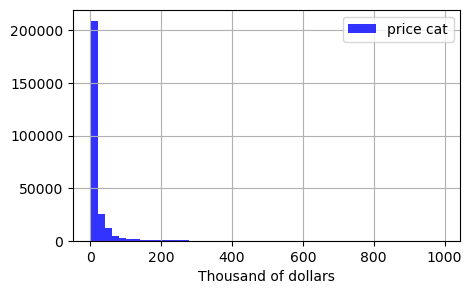

In [ ]:
import matplotlib.pyplot as plt
watches['price_cat'] = np.ceil(watches['price'] / 1e3)
watches['price_cat'].hist(
    bins = 50,
    figsize = (5,3),
    label = 'price cat',
    color = 'blue',
    alpha = 0.8,
)

plt.legend()
plt.xlabel('Thousand of dollars')

watches['price_cat'] = pd.qcut(
    watches['price_cat'],
    q = 5,
    duplicates='drop',
)

watches['price_cat'].sort_values(ascending = False)

In [ ]:
from sklearn.model_selection import train_test_split
strat_train_set, strat_test_set = train_test_split(
    watches,
    test_size = 0.2,
    random_state=42,
    stratify = watches['price_cat']
)
print (f"{strat_train_set.size} train + {strat_test_set.size} set")

2088730 train + 522190 set


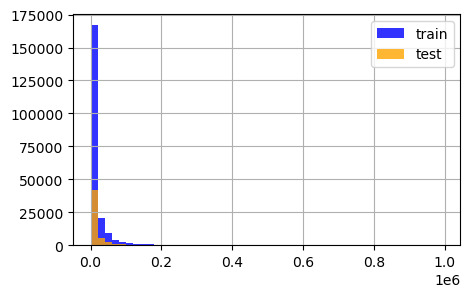

In [ ]:
strat_train_set['price'].hist(
    color = 'blue', 
    alpha = 0.8,
    label = 'train',
    figsize = (5, 3),
    bins = 50
)

strat_test_set['price'].hist(
    color = 'orange', 
    alpha = 0.8,
    label = 'test',
    figsize = (5, 3),
    bins = 50
)

plt.legend()

In [ ]:
if 'price_cat' in strat_train_set.columns:
    strat_train_set = strat_train_set.drop('price_cat', axis = 1)
if 'price_cat' in strat_test_set.columns:
    strat_test_set = strat_test_set.drop('price_cat', axis = 1)
    
watches = strat_train_set.drop ('price', axis = 1).copy()
y = strat_train_set['price'].copy()

# Data Pipeline


In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
class DataFrameSelector (BaseEstimator, TransformerMixin):
    def __init__ (self, attributes):
        self.attributes = attributes
    def fit(self, X, y = None):
        return self
    def transform (self, X):
        return X[self.attributes].values

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.pipeline import FeatureUnion
from sklearn.preprocessing import StandardScaler
from category_encoders import TargetEncoder

num_attribs = watches.select_dtypes(include='float64').columns
cat_attribs = watches.select_dtypes(include='string').columns
num_pipeline = Pipeline([
    ('selector', DataFrameSelector(num_attribs)),
    ('scaler', StandardScaler()),
])

cat_pipeline = Pipeline([
    ('selector', DataFrameSelector(cat_attribs)),
    ('encoder', TargetEncoder()),
])

full_pipeline = FeatureUnion(transformer_list= [
    ('num_pipeline', num_pipeline),
    ('cat_pipeline', cat_pipeline),
])
full_pipeline.fit(watches, y)
x = full_pipeline.transform(watches)

# Model selection


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

lin_reg = LinearRegression()

print (f"\nCross Validation: Linear Regression...")
lin_score = cross_val_score(
    lin_reg, 
    x,
    y,
    cv = 10,
    scoring = 'neg_mean_absolute_percentage_error',
    n_jobs = -1,
    verbose = 2,
)

print (f"\nCV: Linear Regression Finished")


Cross Validation: Linear Regression...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


[CV] END .................................................... total time=   0.2s
[CV] END .................................................... total time=   0.2s
[CV] END .................................................... total time=   0.2s
[CV] END .................................................... total time=   0.2s
[CV] END .................................................... total time=   0.2s
[CV] END .................................................... total time=   0.2s
[CV] END .................................................... total time=   0.2s[CV] END .................................................... total time=   0.2s

[CV] END .................................................... total time=   0.2s
[CV] END .................................................... total time=   0.2s

CV: Linear Regression Finished


[Parallel(n_jobs=-1)]: Done   3 out of  10 | elapsed:    3.7s remaining:    8.6s
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:    3.7s finished


In [ ]:
from sklearn.tree import DecisionTreeRegressor
tree_reg = DecisionTreeRegressor()
print (f"\nCross Validation: Decision Tree...")
tree_score = cross_val_score(
    tree_reg, 
    x,
    y,
    cv = 10,
    scoring = 'neg_mean_absolute_percentage_error',
    n_jobs = -1,
    verbose = 2,
)
print (f"\nCV: Decision Tree Finished")


Cross Validation: Decision Tree...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


[CV] END .................................................... total time=   0.9s
[CV] END .................................................... total time=   0.9s
[CV] END .................................................... total time=   1.0s
[CV] END .................................................... total time=   1.0s


[Parallel(n_jobs=-1)]: Done   3 out of  10 | elapsed:    1.1s remaining:    2.5s


[CV] END .................................................... total time=   0.8s
[CV] END .................................................... total time=   0.8s
[CV] END .................................................... total time=   0.8s
[CV] END .................................................... total time=   0.9s
[CV] END .................................................... total time=   0.9s
[CV] END .................................................... total time=   0.9s

CV: Decision Tree Finished


[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:    2.3s finished


In [ ]:
from sklearn.ensemble import RandomForestRegressor
forest_reg = RandomForestRegressor()
print (f"\nCross Validation: Random Forest...")
forest_score = cross_val_score(
    forest_reg, 
    x,
    y,
    cv = 10,
    scoring = 'neg_mean_absolute_percentage_error', 
    n_jobs = -1,
    verbose = 2,
)
print (f"\nCV: Random Forest Finished")


Cross Validation: Random Forest...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


In [ ]:
def display_score(score: np.ndarray):
    score = -score
    print ("Scores:", score)
    print ("Standard Deviation:", score.std())
    print("Mean:", score.mean())

print ('\n-------Linear Regresssion-------')
display_score(lin_score)

print ('\n-------Tree Regresssion-------')
display_score(tree_score)

print ('\n-------Forest Regresssion-------')
display_score(forest_score)


-------Linear Regresssion-------
Scores: [1.50928164 1.46672884 1.54165054 1.49180054 1.53307519 1.58144072
 1.56200925 1.4854991  1.51883462 1.57160215]
Standard Deviation: 0.036603780160190176
Mean: 1.5261922592491444

-------Tree Regresssion-------
Scores: [0.27913881 0.27044097 0.30120797 0.27759001 0.23989472 0.34968337
 0.27288202 0.30659484 0.30802271 0.35128537]
Standard Deviation: 0.03343646017334256
Mean: 0.29567407913714744

-------Forest Regresssion-------
Scores: [0.25100447 0.27058326 0.28032493 0.28630702 0.24352651 0.32933694
 0.25819565 0.27098259 0.28997222 0.30886482]
Standard Deviation: 0.02492234085905374
Mean: 0.27890983835282385


# Randomized Search


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
tree_param_grid = {
    'max_depth': [3, 5, 8, 12, None],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 6],
}
tree_search = RandomizedSearchCV (
    DecisionTreeRegressor(),
    param_distributions=tree_param_grid,
    random_state = 42,
    scoring = "neg_mean_absolute_percentage_error",
    verbose = 3, 
    n_jobs = -1,
)
tree_search.fit (x, y)


Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeRegressor()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_absolute_percentage_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:

In [ ]:
tree_score = cross_val_score (
    tree_search.best_estimator_,
    x, 
    y,
    cv = 5,
    scoring = 'neg_mean_absolute_percentage_error',
    n_jobs = -1,
)

display_score (tree_score)

Scores: [0.25909977 0.289135   0.30779452 0.27089494 0.31998786]
Standard Deviation: 0.022514820157634105
Mean: 0.2893824192894705


In [ ]:
forest_param_grid = {
    'n_estimators': [3, 10, 30, 50], 
    'max_features': [2,3,5,6,8],
    'bootstrap': [True, False]
}
forest_search = RandomizedSearchCV(
    RandomForestRegressor(),
    forest_param_grid,
    verbose = 3,
    scoring = "neg_mean_absolute_percentage_error",
    random_state=42,
    n_jobs = -1,
)
forest_search.fit (x, y)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestRegressor()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'bootstrap': [True, False], 'max_features': [2, 3, ...], 'n_estimators': [3, 10, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_absolute_percentage_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22

In [ ]:
forest_score = cross_val_score(
    forest_search.best_estimator_, 
    x,
    y,
    cv = 5, 
    scoring = 'neg_mean_absolute_percentage_error',
    n_jobs = -1,
)

display_score (forest_score)

Scores: [0.26343701 0.2679421  0.28373059 0.26916338 0.29746248]
Standard Deviation: 0.012564198415403637
Mean: 0.2763471139047268


# Validate on test set


In [ ]:
watches_test = strat_test_set.drop ('price', axis = 1).copy()
x_test = full_pipeline.transform (watches_test)
y_test = strat_test_set['price'].copy()

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error
tree_model = tree_search.best_estimator_
tree_model.fit (x_test, y_test)
prediction = tree_model.predict (x_test)
print (f"\n-------Decision Tree-------")
print(f"MAPE error: {mean_absolute_percentage_error(prediction, y_test)}")


-------Decision Tree-------
MAPE error: 0.16890260111741304


In [ ]:
forest_model = forest_search.best_estimator_
forest_model.fit (x_test, y_test)
prediction = forest_model.predict(x_test)
print (f"\n-------Random Forest-------")
print (f"MAPE:{mean_absolute_percentage_error(prediction, y_test)}")


-------Random Forest-------
MAPE:0.07606675168263016


In [ ]:
from sklearn.dummy import DummyRegressor
dummy = DummyRegressor(strategy='median')
dummy.fit (x_test, y_test)
prediction = dummy.predict (x_test)
print (f'\n-------Dummy-------')
print (f"MAPE error: {mean_absolute_percentage_error(prediction, y_test)}")


-------Dummy-------
MAPE error: 2.066298760906985
